
###import the main libraries

In [1]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 4.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
plasma_palette=sns.color_palette("plasma")
cool_palette=sns.color_palette("cool")
viridis_palette=sns.color_palette("viridis")
inferno_palette=sns.color_palette("inferno")
icefire_palette=sns.color_palette("icefire")
icefire_r_palette=sns.color_palette("icefire_r")
mako_palette=sns.color_palette("mako")
COLORS = {
    "hist": "steelblue",
    "box": "cornflowerblue",
    "scatter": "teal",
    "heatmap": "coolwarm",
    "bar_palette": "viridis"
}
sns.color_palette('Blues')

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("weatherAUS.csv")

### Drop  RISK_MM variable

It is given in the dataset description, that we should drop the `RISK_MM` feature variable from the dataset description. So, we
should drop it as follows-

In [4]:
df.drop(['RISK_MM'], axis=1, inplace=True)
df.shape
df.head()
df.info()
print(f"Total missing values :{df.isnull().sum().sum()}")
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null

,0
Date,0
Location,0
MinTemp,637
MaxTemp,322
Rainfall,1406
Evaporation,60843
Sunshine,67816
WindGustDir,9330
WindGustSpeed,9270
WindDir9am,10013


In [5]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df.drop('Date', axis=1, inplace = True)

### Explore Categorical Variables





Now, I will explore the categorical variables one by one.

In [6]:
categorical= df.select_dtypes(include="object").columns.to_list()
print('There are {} categorical variables\n'.format(len(categorical)))

print('The categorical variables are :', categorical)

There are 6 categorical variables

The categorical variables are : ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


In [7]:
from IPython.display import display
import pandas as pd

# 1. Explore Location variable
print("========== 1. Location ==========")
display(df.Location.dtypes)
df["Location"] = df["Location"].astype("object")
print('Location contains', len(df.Location.unique()), 'labels')
display(df.Location.unique())
display(df.Location.value_counts())
display(pd.get_dummies(df.Location, drop_first=True).head())

# 2. Explore WindGustDir variable
print("\n========== 2. WindGustDir ==========")
df["WindGustDir"] = df["WindGustDir"].astype("object")
print('WindGustDir contains', len(df['WindGustDir'].unique()), 'labels')
display(df.WindGustDir.value_counts())
display(pd.get_dummies(df.WindGustDir, drop_first=True, dummy_na=True).head())
display(pd.get_dummies(df.WindGustDir, drop_first=True, dummy_na=True).sum())

# 3. Explore WindDir9am variable
print("\n========== 3. WindDir9am ==========")
df["WindDir9am"] = df["WindDir9am"].astype("object")
print('WindDir9am contains', len(df['WindDir9am'].unique()), 'labels')
display(df['WindDir9am'].unique())
display(pd.get_dummies(df.WindDir9am, drop_first=True, dummy_na=True).head())
display(pd.get_dummies(df.WindDir9am, drop_first=True, dummy_na=True).sum(axis=0))

# 4. Explore WindDir3pm variable
print("\n========== 4. WindDir3pm ==========")
df["WindDir3pm"] = df["WindDir3pm"].astype("object")
print('WindDir3pm contains', len(df['WindDir3pm'].unique()), 'labels')
display(df.WindDir3pm.unique())
display(df['WindDir3pm'].value_counts())
display(pd.get_dummies(df.WindDir3pm, drop_first=True, dummy_na=True).head())
display(pd.get_dummies(df.WindDir3pm, drop_first=True, dummy_na=True).sum(axis=0))

# 5. Explore RainToday and RainTomorrow variables
print("\n========== 5. RainToday & RainTomorrow ==========")
df["RainToday"] = df["RainToday"].astype("object")
df["RainTomorrow"] = df["RainTomorrow"].astype("object")
print('RainToday contains', len(df['RainToday'].unique()), 'labels')
display(df['RainToday'].unique())
display(df.RainToday.value_counts())
display(pd.get_dummies(df.RainToday, drop_first=True, dummy_na=True).head())
display(pd.get_dummies(df.RainToday, drop_first=True, dummy_na=True).sum(axis=0))

========== 1. Location ==========


dtype('O')

Location contains 49 labels


array(['Albury', 'BadgerysCreek', 'Cobar', 'CoffsHarbour', 'Moree',
       'Newcastle', 'NorahHead', 'NorfolkIsland', 'Penrith', 'Richmond',
       'Sydney', 'SydneyAirport', 'WaggaWagga', 'Williamtown',
       'Wollongong', 'Canberra', 'Tuggeranong', 'MountGinini', 'Ballarat',
       'Bendigo', 'Sale', 'MelbourneAirport', 'Melbourne', 'Mildura',
       'Nhil', 'Portland', 'Watsonia', 'Dartmoor', 'Brisbane', 'Cairns',
       'GoldCoast', 'Townsville', 'Adelaide', 'MountGambier', 'Nuriootpa',
       'Woomera', 'Albany', 'Witchcliffe', 'PearceRAAF', 'PerthAirport',
       'Perth', 'SalmonGums', 'Walpole', 'Hobart', 'Launceston',
       'AliceSprings', 'Darwin', 'Katherine', 'Uluru'], dtype=object)

,count
Location,
Canberra,3418
Sydney,3337
Perth,3193
Darwin,3192
Hobart,3188
Brisbane,3161
Adelaide,3090
Bendigo,3034
Townsville,3033


...


========== 5. RainToday & RainTomorrow ==========
RainToday contains 3 labels


array(['No', 'Yes', nan], dtype=object)

,count
RainToday,
No,109332
Yes,31455


,Yes,NaN
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False


,0
Yes,31455
NaN,1406


In [8]:
# find numerical variables

numerical = [var for var in df.columns if df[var].dtype!='O']

print('There are {} numerical variables\n'.format(len(numerical)))

print('The numerical variables are :', numerical)
df[numerical].info()
print(df.shape)
df[numerical].isnull().sum()
print(round(df[numerical].describe()),2)

There are 19 numerical variables

The numerical variables are : ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'Year', 'Month', 'Day']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   MinTemp        141556 non-null  float64
 1   MaxTemp        141871 non-null  float64
 2   Rainfall       140787 non-null  float64
 3   Evaporation    81350 non-null   float64
 4   Sunshine       74377 non-null   float64
 5   WindGustSpeed  132923 non-null  float64
 6   WindSpeed9am   140845 non-null  float64
 7   WindSpeed3pm   139563 non-null  float64
 8   Humidity9am    140419 non-null  float64
 9   Humidity3pm    138583 non-null  float64
 10  Pressure9am    128179 non-null  float64

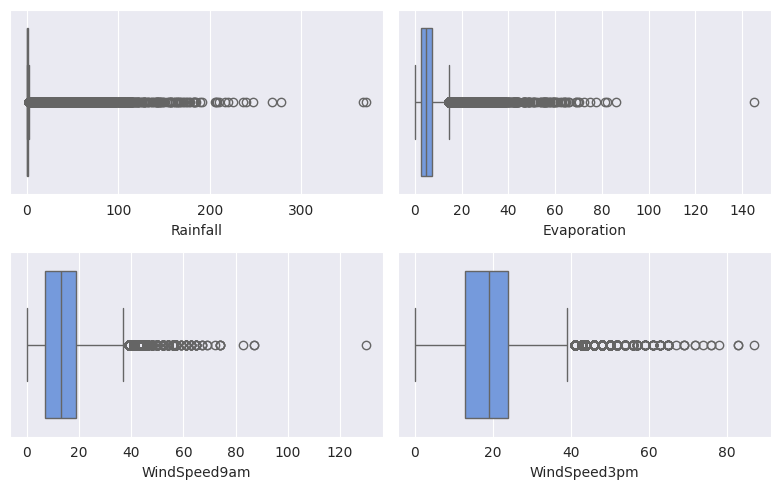

In [9]:
# draw boxplots to visualize outliers

fig, axes = plt.subplots(2 ,2 ,figsize = (8,5))

sns.boxplot(data=df, x="Rainfall", color=COLORS["box"],ax = axes[0,0])
sns.boxplot(data=df, x="Evaporation", color=COLORS["box"],ax=axes[0, 1])
sns.boxplot(data=df, x="WindSpeed9am", color=COLORS["box"],ax=axes[1, 0])
sns.boxplot(data=df, x="WindSpeed3pm", color=COLORS["box"], ax=axes[1, 1])

plt.tight_layout()
plt.show()

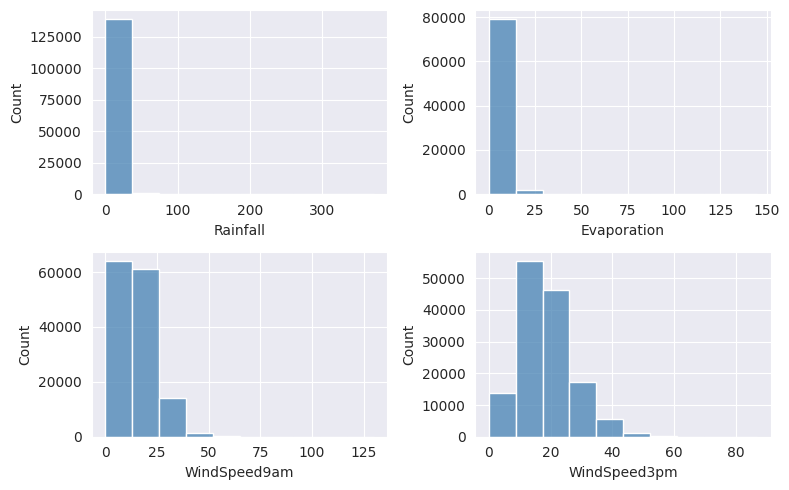

In [10]:
# check Distribution

fig, axes = plt.subplots(2,2, figsize = (8,5))

sns.histplot(data = df, x="Rainfall", color=COLORS["hist"], ax=axes[0,0], bins= 10)

sns.histplot(data=df, x="Evaporation", color=COLORS["hist"],ax=axes[0, 1],bins= 10)

sns.histplot(data=df, x="WindSpeed9am", color=COLORS["hist"],ax=axes[1, 0], bins= 10)

sns.histplot(data=df, x="WindSpeed3pm", color=COLORS["hist"], ax=axes[1, 1], bins= 10)

plt.tight_layout()
plt.show()

In [11]:
# function to find outliers
def find_outliers(column):
    IQR = df[column].quantile(0.75) - df[column].quantile(0.25)

    lower_fence = df[column].quantile(0.25) - (IQR * 3)
    upper_fence = df[column].quantile(0.75) + (IQR * 3)

    outliers = df[
        (df[column] < lower_fence ) |
        (df[column] > upper_fence )
    ]

    percentage = len(outliers) / len(df) * 100

    print(f'{column} outliers are values < {lower_fence} or > {upper_fence}')
    print(f"outliers length of {column} : {len(outliers)}")
    print(f"outliers perecntage is :{percentage:.2f}%")

In [12]:
numerical = [var for var in df.columns if df[var].dtype != 'O']
categorical = [var for var in df.columns if df[var].dtype == 'O']

print(f"Number of numerical variables: {len(numerical)}")
print(f"Number of categorical variables: {len(categorical)}")

#median in numerical
for col in numerical:
    col_median = df[col].median()
    df[col] = df[col].fillna(col_median)

#mode in categorical
for col in categorical:
    if not df[col].mode().empty:
        most_freq = df[col].mode()[0]
        df[col] = df[col].fillna(most_freq)
#Run a check
print("\nMissing values after imputation:")
print(df.isnull().sum().max())

Number of numerical variables: 19
Number of categorical variables: 6

Missing values after imputation:
0


In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(['RainTomorrow'], axis=1)
y = df['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (113754, 24)
X_test shape: (28439, 24)


####decision tree

In [14]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# ENCODING CATEGORICAL VARIABLES
X_train_encoded_dt = pd.get_dummies(X_train, drop_first=True)
X_test_encoded_dt = pd.get_dummies(X_test, drop_first=True)

# Align columns to prevent any mismatch errors
X_train_encoded_dt, X_test_encoded_dt = X_train_encoded_dt.align(X_test_encoded_dt, join='left', axis=1, fill_value=0)

print("\nTraining the Decision Tree model...")
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model.fit(X_train_encoded_dt, y_train)

y_pred_dt = dt_model.predict(X_test_encoded_dt)

print(classification_report(y_test, y_pred_dt))

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Overall Accuracy: {accuracy_dt:.4f}")


Training the Decision Tree model...
              precision    recall  f1-score   support

          No       0.87      0.87      0.87     22067
         Yes       0.55      0.54      0.55      6372

    accuracy                           0.80     28439
   macro avg       0.71      0.71      0.71     28439
weighted avg       0.80      0.80      0.80     28439

Decision Tree Overall Accuracy: 0.7967


using custom weight method

              precision    recall  f1-score   support

          No       0.93      0.72      0.81     22067
         Yes       0.46      0.82      0.59      6372

    accuracy                           0.74     28439
   macro avg       0.69      0.77      0.70     28439
weighted avg       0.82      0.74      0.76     28439

Decision Tree Overall Accuracy: 0.7411


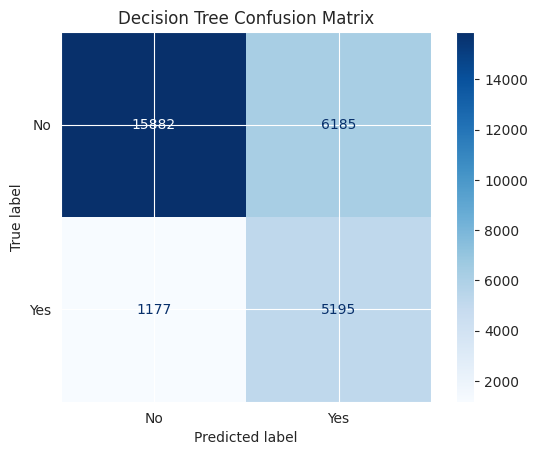

In [15]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

weights = {'No': 1.0, 'Yes': 5.0}

dt_model = DecisionTreeClassifier(class_weight=weights, max_depth=10, random_state=42)
dt_model.fit(X_train_encoded_dt, y_train)

y_pred_dt = dt_model.predict(X_test_encoded_dt)

print(classification_report(y_test, y_pred_dt))

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Overall Accuracy: {accuracy_dt:.4f}")
cm_dt = confusion_matrix(y_test, y_pred_dt)

#confusion matrix
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=dt_model.classes_)
disp_dt.plot(cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.show()

###Roc curve

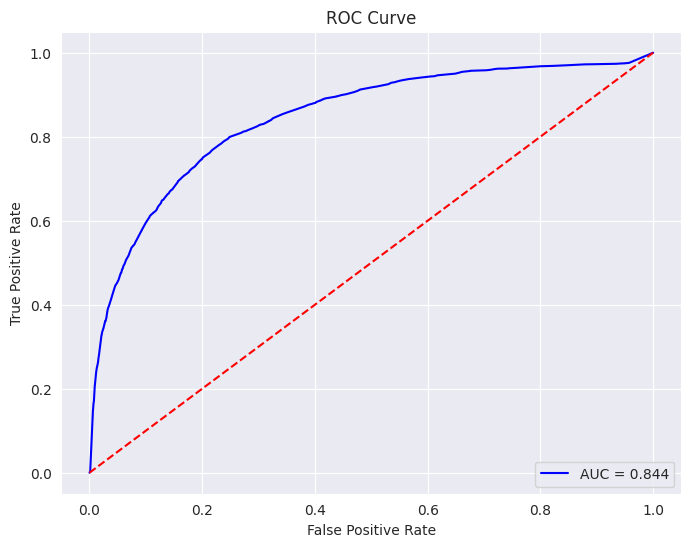

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = dt_model.predict_proba(X_test_encoded_dt)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label='Yes')
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", color="blue")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

#####Random forest

In [17]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. ENCODING CATEGORICAL VARIABLES
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

print(f"Training features shape: {X_train_encoded.shape}")
print(f"Testing features shape: {X_test_encoded.shape}")

# 2. MODEL TRAINING
print("\nTraining the Random Forest model... (This might take a minute)")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced_subsample', random_state=42)

# Fit the model using the encoded training data
rf_model.fit(X_train_encoded, y_train)

# 3. PREDICTION & EVALUATION
y_pred = rf_model.predict(X_test_encoded)

# Print the classification report (Precision, Recall, F1-Score)
print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred))

# Calculate and print the overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.4f}")

Training features shape: (113754, 113)
Testing features shape: (28439, 113)

Training the Random Forest model... (This might take a minute)

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

          No       0.87      0.96      0.91     22067
         Yes       0.80      0.49      0.61      6372

    accuracy                           0.86     28439
   macro avg       0.83      0.73      0.76     28439
weighted avg       0.85      0.86      0.84     28439

Overall Accuracy: 0.8574


Using threshold method

--- Classification Report (Threshold = 0.3) ---
              precision    recall  f1-score   support

          No       0.92      0.86      0.89     22067
         Yes       0.61      0.75      0.67      6372

    accuracy                           0.84     28439
   macro avg       0.77      0.81      0.78     28439
weighted avg       0.85      0.84      0.84     28439

Overall Accuracy: 0.8366

Displaying Random Forest Confusion Matrix...


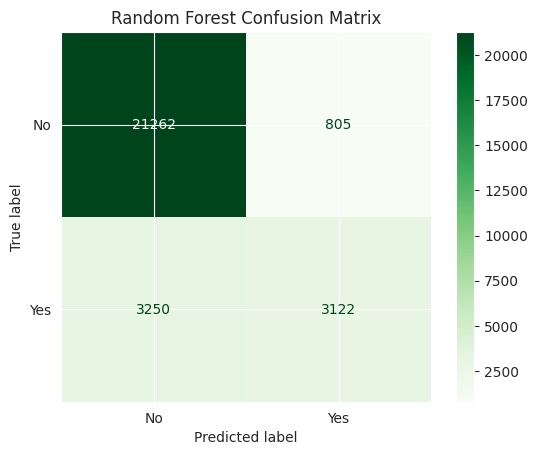

In [18]:
import numpy as np

y_probs = rf_model.predict_proba(X_test_encoded)[:, 1]

threshold = 0.30

y_pred_custom = np.where(y_probs >= threshold, 'Yes', 'No')

print(f"--- Classification Report (Threshold = {threshold}) ---")
print(classification_report(y_test, y_pred_custom))

from sklearn.metrics import accuracy_score
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_custom):.4f}")
cm_rf = confusion_matrix(y_test, y_pred)

print("\nDisplaying Random Forest Confusion Matrix...")
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
disp_rf.plot(cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.show()

## Roc curve

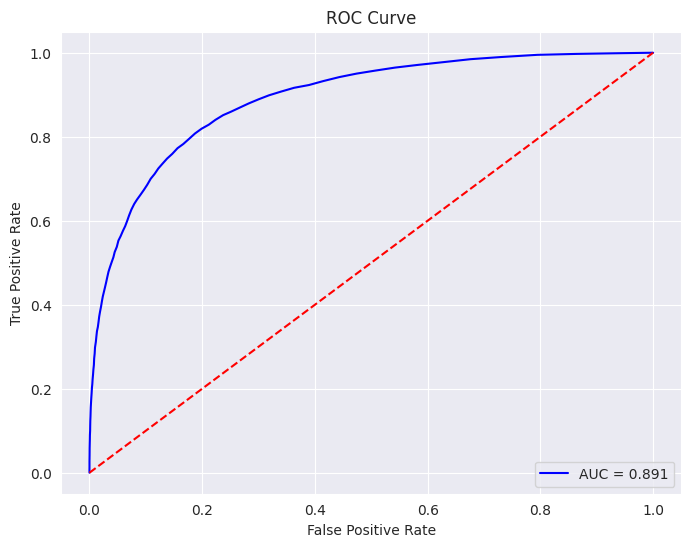

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = rf_model.predict_proba(X_test_encoded)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label='Yes')
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", color="blue")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

##Logisitic regression

##importing the main libraries

In [20]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

dealing with outliers

In [21]:
import numpy as np

#using log transform on rainfall
X_train_encoded_dt['Rainfall'] = np.log1p(X_train_encoded_dt['Rainfall'])
X_test_encoded_dt['Rainfall'] = np.log1p(X_test_encoded_dt['Rainfall'])

#capping
def max_value(df, col, top):
    return np.where(df[col] > top, top, df[col])

#applying capping on the needed columns
X_train_encoded_dt['Evaporation'] = max_value(X_train_encoded_dt, 'Evaporation', 21.8)
X_test_encoded_dt['Evaporation'] = max_value(X_test_encoded_dt, 'Evaporation', 21.8)

X_train_encoded_dt['WindSpeed9am'] = max_value(X_train_encoded_dt, 'WindSpeed9am', 55)
X_test_encoded_dt['WindSpeed9am'] = max_value(X_test_encoded_dt, 'WindSpeed9am', 55)

X_train_encoded_dt['WindSpeed3pm'] = max_value(X_train_encoded_dt, 'WindSpeed3pm', 57)
X_test_encoded_dt['WindSpeed3pm'] = max_value(X_test_encoded_dt, 'WindSpeed3pm', 57)

##feature scaling

In [22]:
# 1. Feature Scaling
scaler = MinMaxScaler()
#using the same encoded data in decision tree
X_train_scaled = scaler.fit_transform(X_train_encoded_dt)
X_test_scaled = scaler.transform(X_test_encoded_dt)

##the plotting functions

In [23]:
#the plotting functions
def plot_roc_curve_custom(y_true, y_prob, title):
#adding pos_label to avoid error
    fpr, tpr, _ = roc_curve(y_true, y_prob, pos_label='Yes')
    auc = roc_auc_score(y_true, y_prob)

    plt.figure(figsize=(7,5))
    plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.3f}")
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()

Logistic regression(standard)


Standard Logistic Regression
Accuracy: 0.8506

Classification Report:
              precision    recall  f1-score   support

          No       0.87      0.95      0.91     22067
         Yes       0.74      0.52      0.61      6372

    accuracy                           0.85     28439
   macro avg       0.80      0.73      0.76     28439
weighted avg       0.84      0.85      0.84     28439



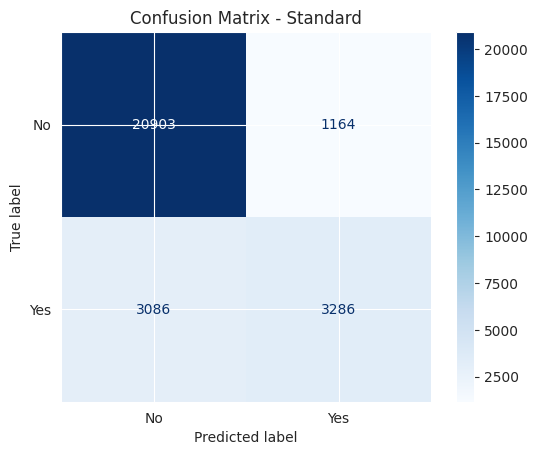

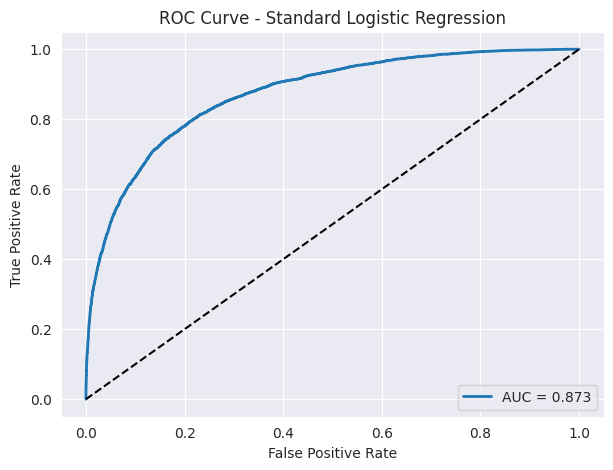

In [24]:
# 3. Logistic Regression (Standard)
print("\n" + "="*60)
print("Standard Logistic Regression")
print("="*60)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

#the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Standard")
plt.show()
#Roc curve
plot_roc_curve_custom(y_test, y_prob, "ROC Curve - Standard Logistic Regression")

detcting imbalance

In [25]:
# 4. Detecting Imbalance
print("\nDetecting Imbalance in Target Variable:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))



Detecting Imbalance in Target Variable:
RainTomorrow
No     88249
Yes    25505
Name: count, dtype: int64
RainTomorrow
No     0.775788
Yes    0.224212
Name: proportion, dtype: float64


Logisitic regression (balanced)


Balanced Logistic Regression
Accuracy: 0.7973

Classification Report:
              precision    recall  f1-score   support

          No       0.93      0.80      0.86     22067
         Yes       0.53      0.78      0.63      6372

    accuracy                           0.80     28439
   macro avg       0.73      0.79      0.75     28439
weighted avg       0.84      0.80      0.81     28439



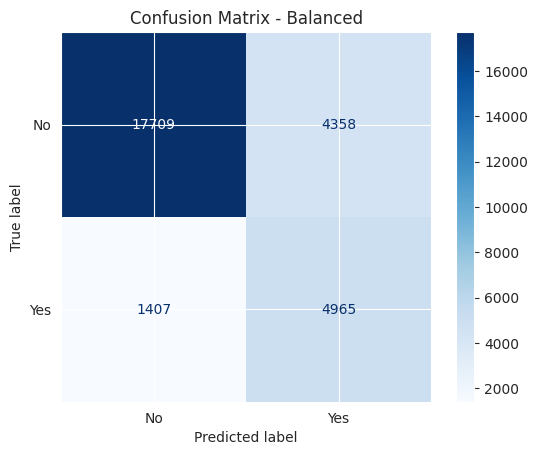

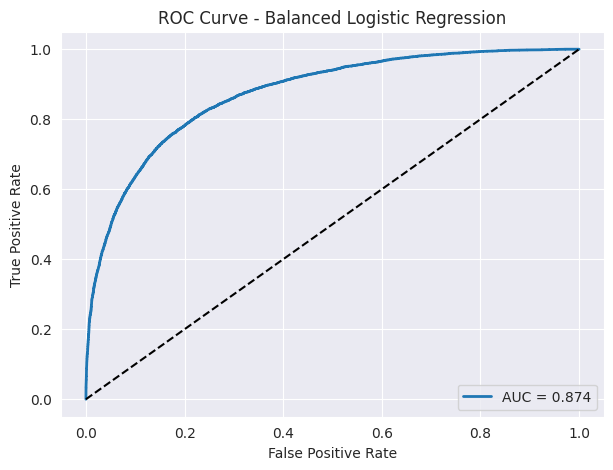

In [26]:
# 5. Logistic Regression (Balanced)
print("\n" + "="*60)
print("Balanced Logistic Regression")
print("="*60)

model_balanced = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)
y_prob_balanced = model_balanced.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_balanced):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_balanced))

cm_bal = confusion_matrix(y_test, y_pred_balanced)
disp_bal = ConfusionMatrixDisplay(confusion_matrix=cm_bal, display_labels=model_balanced.classes_)
disp_bal.plot(cmap='Blues')
plt.title("Confusion Matrix - Balanced")
plt.show()

plot_roc_curve_custom(y_test, y_prob_balanced, "ROC Curve - Balanced Logistic Regression")

Logistic Regression (Custom Threshold)


Threshold Logistic Regression (Threshold = 0.35)
Accuracy: 0.8386

Classification Report:
              precision    recall  f1-score   support

          No       0.90      0.89      0.90     22067
         Yes       0.64      0.65      0.64      6372

    accuracy                           0.84     28439
   macro avg       0.77      0.77      0.77     28439
weighted avg       0.84      0.84      0.84     28439



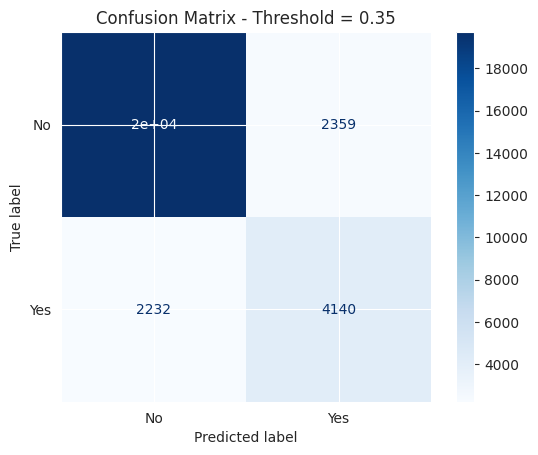

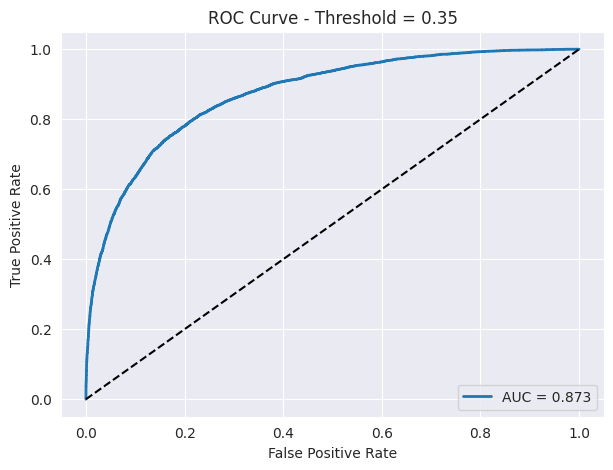

In [27]:
# 6. Logistic Regression (Custom Threshold)
threshold = 0.35
print("\n" + "="*60)
print(f"Threshold Logistic Regression (Threshold = {threshold})")
print("="*60)

y_pred_threshold = (y_prob >= threshold)
#turning true and false to yes and no
y_pred_threshold_labels = ['Yes' if val else 'No' for val in y_pred_threshold]

print(f"Accuracy: {accuracy_score(y_test, y_pred_threshold_labels):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_threshold_labels))

#confusion matrix
cm_thresh = confusion_matrix(y_test, y_pred_threshold_labels)
disp_thresh = ConfusionMatrixDisplay(confusion_matrix=cm_thresh, display_labels=['No', 'Yes'])
disp_thresh.plot(cmap='Blues')
plt.title(f"Confusion Matrix - Threshold = {threshold}")
plt.show()
#roc curve
plot_roc_curve_custom(y_test, y_prob, f"ROC Curve - Threshold = {threshold}")

##naive bias

##import the main libraries

In [30]:
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics



building the model

In [31]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

predicted = nb_model.predict(X_test_scaled)

print("=" * 50)
print("NAIVE BAYES CLASSIFICATION REPORT")
print("=" * 50)
print(metrics.classification_report(y_test, predicted))
print(f"Accuracy Score: {metrics.accuracy_score(y_test, predicted):.4f}")

NAIVE BAYES CLASSIFICATION REPORT
              precision    recall  f1-score   support

          No       0.89      0.62      0.73     22067
         Yes       0.36      0.73      0.48      6372

    accuracy                           0.65     28439
   macro avg       0.62      0.68      0.61     28439
weighted avg       0.77      0.65      0.68     28439

Accuracy Score: 0.6460


the confusion matrix

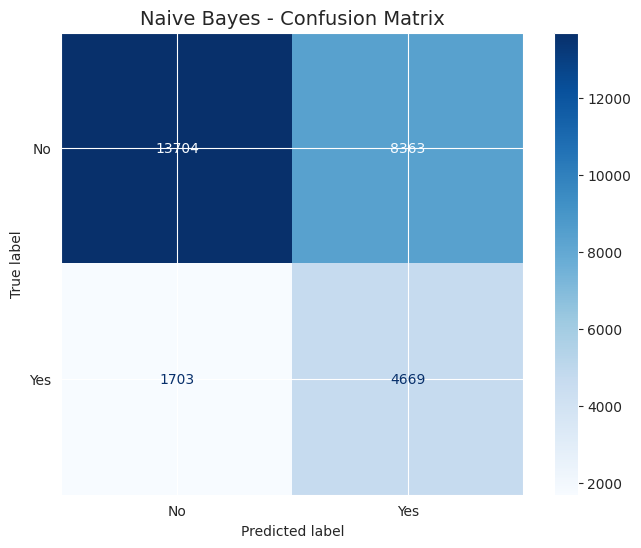

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# 1. Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, predicted, cmap='Blues', ax=ax)
plt.title("Naive Bayes - Confusion Matrix", fontsize=14)
plt.show()



ROC curve

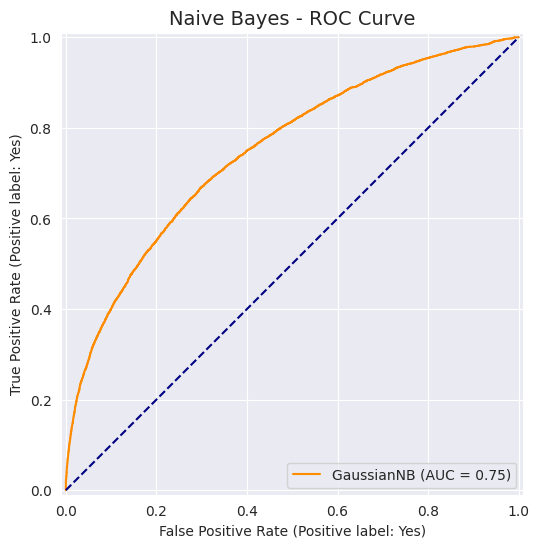

In [33]:
# 2. ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(nb_model, X_test_scaled, y_test, ax=ax, color='darkorange')
plt.title("Naive Bayes - ROC Curve", fontsize=14)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.show()

##overall review of all models

In [34]:
import pandas as pd
from sklearn.metrics import accuracy_score


models_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Naive Bayes'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_threshold_labels),  # Logistic Regression
        accuracy_dt,                                      # Decision Tree
        accuracy,                                         # Random Forest
        accuracy_score(y_test, predicted)                 # Naive Bayes
    ]
})


display(models_comparison.sort_values(by='Accuracy', ascending=False).style.background_gradient(cmap='Blues'))

,Model,Accuracy
2,Random Forest,0.857414
0,Logistic Regression,0.838567
1,Decision Tree,0.741130
3,Naive Bayes,0.646049
